# Step 5 — Word Embeddings: BoW, Word2Vec, GloVe
**Project:** SDG Mapping for PhD Thesis  
**Purpose:** Replace TF-IDF sparse features with dense vector representations and compare classifier performance  
**Inputs:** `data/clean/X_train_emb.csv` · `data/clean/X_test_emb.csv` · `data/clean/mahe_emb.csv`  
**Outputs:** `data/results/step5_embedding_comparison.csv` · `data/results/mahe_top5_glove.csv`  

> Three representations compared:  
> - **BoW** (Bag of Words) — count-based, no semantics  
> - **Word2Vec** — trained on your OSDG corpus  
> - **GloVe** — pre-trained on Wikipedia + Gigaword (requires download)  
> Each fed into the same 4 classifiers from Step 4 for fair comparison.


In [1]:
# Cell 1: Install dependencies 
!pip install pandas numpy scikit-learn xgboost gensim matplotlib seaborn tqdm

In [2]:
# Cell 2: Imports & setup 
import json
import warnings
import requests
import zipfile
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from tqdm.notebook import tqdm
from gensim.models import Word2Vec
from gensim.utils import simple_preprocess
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

CLEAN_DIR   = Path("data/clean")
RESULTS_DIR = Path("data/results")
PLOT_DIR    = Path("data/plots")
MODELS_DIR  = Path("data/models")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

with open("data/step2_meta.json") as f:
    meta = json.load(f)
SDG_NAMES = {int(k): v for k, v in meta["sdg_names"].items()}

print("✅ Imports complete")


✅ Imports complete


In [3]:
# Cell 3: Load data 
X_train_raw = pd.read_csv(CLEAN_DIR / "X_train_emb.csv")["text"].fillna("").tolist()
X_test_raw  = pd.read_csv(CLEAN_DIR / "X_test_emb.csv")["text"].fillna("").tolist()
y_train     = pd.read_csv(CLEAN_DIR / "y_train.csv")["sdg"].tolist()
y_test      = pd.read_csv(CLEAN_DIR / "y_test.csv")["sdg"].tolist()
mahe_raw    = pd.read_csv(CLEAN_DIR / "mahe_emb.csv")["text"].fillna("").tolist()
mahe_df     = pd.read_csv(CLEAN_DIR / "mahe_corpus.csv")

classes       = sorted(set(y_train))
label_map     = {sdg: idx for idx, sdg in enumerate(classes)}
label_map_inv = {idx: sdg for sdg, idx in label_map.items()}

y_train_enc = np.array([label_map[y] for y in y_train])
y_test_enc  = np.array([label_map[y] for y in y_test])

print(f"X_train : {len(X_train_raw):,} samples")
print(f"X_test  : {len(X_test_raw):,}  samples")
print(f"MAHE    : {len(mahe_raw):,}  documents")
print(f"Classes : {len(classes)} SDGs")


X_train : 27,204 samples
X_test  : 6,801  samples
MAHE    : 854  documents
Classes : 16 SDGs


In [4]:
# Cell 4: Helper — vectorize documents using mean word embeddings 
def docs_to_vectors(texts, model_vocab, vector_size, word_vectors):
    """
    Convert a list of texts to document vectors by averaging word vectors.
    Words not in vocabulary are skipped.
    Documents with no known words get a zero vector.
    """
    vectors = []
    for text in texts:
        tokens = text.split()
        valid  = [word_vectors[w] for w in tokens if w in model_vocab]
        if valid:
            vectors.append(np.mean(valid, axis=0))
        else:
            vectors.append(np.zeros(vector_size))
    return np.array(vectors)


def train_and_evaluate(X_tr, X_te, y_tr, y_te, label_map, label_map_inv, tag=""):
    """
    Train all 4 classifiers on given feature matrices.
    Returns dict of results and dict of trained models.
    """
    classifiers = {
        "Logistic Regression": LogisticRegression(
            C=1.0, max_iter=1000, class_weight="balanced",
            multi_class="multinomial", solver="lbfgs", random_state=42),
        "SVM": CalibratedClassifierCV(
            LinearSVC(C=1.0, max_iter=2000,
                      class_weight="balanced", random_state=42)),
        "Random Forest": RandomForestClassifier(
            n_estimators=200, max_depth=20,
            class_weight="balanced_subsample",
            random_state=42, n_jobs=-1),
        "XGBoost": XGBClassifier(
            n_estimators=200, max_depth=6, learning_rate=0.1,
            eval_metric="mlogloss", random_state=42,
            n_jobs=-1, verbosity=0),
    }

    results  = {}
    trained  = {}

    for name, clf in classifiers.items():
        if name == "XGBoost":
            y_tr_in = np.array([label_map[y] for y in y_tr])
            y_te_in = np.array([label_map[y] for y in y_te])
            clf.fit(X_tr, y_tr_in)
            y_pred_enc = clf.predict(X_te)
            y_pred = np.array([label_map_inv[i] for i in y_pred_enc])
        else:
            clf.fit(X_tr, y_tr)
            y_pred = clf.predict(X_te)

        results[name] = {
            "Macro F1":        round(f1_score(y_te, y_pred, average="macro",    zero_division=0), 4),
            "Macro Precision": round(precision_score(y_te, y_pred, average="macro", zero_division=0), 4),
            "Macro Recall":    round(recall_score(y_te, y_pred, average="macro",    zero_division=0), 4),
            "Accuracy":        round(accuracy_score(y_te, y_pred), 4),
            "Representation":  tag,
        }
        trained[name] = clf
        print(f"  {name:<25} F1={results[name]['Macro F1']:.4f}")

    return results, trained

print("✅ Helper functions defined")


✅ Helper functions defined


In [5]:
# Cell 5: Representation 1 — Bag of Words (BoW) 
print("=" * 50)
print("  Representation 1: Bag of Words")
print("=" * 50)

bow_vec = CountVectorizer(max_features=30000, min_df=2, max_df=0.95)
X_train_bow = bow_vec.fit_transform(X_train_raw)
X_test_bow  = bow_vec.transform(X_test_raw)
X_mahe_bow  = bow_vec.transform(mahe_raw)

print(f"BoW matrix shape: {X_train_bow.shape}")
print()

results_bow, trained_bow = train_and_evaluate(
    X_train_bow, X_test_bow,
    y_train, y_test,
    label_map, label_map_inv,
    tag="BoW"
)
print("\n✅ BoW complete")


  Representation 1: Bag of Words
BoW matrix shape: (27204, 24298)

  Logistic Regression       F1=0.7970
  SVM                       F1=0.7933
  Random Forest             F1=0.7494
  XGBoost                   F1=0.7981

✅ BoW complete


In [6]:
# Cell 6: Representation 2 — Word2Vec (trained on OSDG corpus) 
print("=" * 50)
print("  Representation 2: Word2Vec")
print("=" * 50)
print("Training Word2Vec on OSDG training corpus...")

# Tokenize for Word2Vec
train_sentences = [simple_preprocess(text) for text in X_train_raw]

# Train Word2Vec
# vector_size=300 matches GloVe dimensions for fair comparison
# window=5 = standard context window
# min_count=2 = ignore rare words
# workers=4 = parallel training
w2v_model = Word2Vec(
    sentences=train_sentences,
    vector_size=300,
    window=5,
    min_count=2,
    workers=4,
    epochs=10,
    seed=42,
)
w2v_model.save(str(MODELS_DIR / "word2vec_osdg.model"))

print(f"Word2Vec trained:")
print(f"  Vocabulary size : {len(w2v_model.wv):,} words")
print(f"  Vector size     : 300 dimensions")
print(f"  Trained on      : {len(train_sentences):,} documents")
print()

# Sample similarity check
test_words = ["health", "climate", "poverty", "education"]
for word in test_words:
    if word in w2v_model.wv:
        similar = w2v_model.wv.most_similar(word, topn=3)
        similar_str = ", ".join([f"{w}({s:.2f})" for w, s in similar])
        print(f"  '{word}' most similar: {similar_str}")


  Representation 2: Word2Vec
Training Word2Vec on OSDG training corpus...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Word2Vec trained:
  Vocabulary size : 25,626 words
  Vector size     : 300 dimensions
  Trained on      : 27,204 documents

  'health' most similar: illness(0.56), healthcare(0.54), ambulatory(0.51)
  'climate' most similar: adaptation(0.61), hearts(0.58), mitigation(0.57)
  'poverty' most similar: deprivation(0.71), inequality(0.55), indigence(0.53)
  'education' most similar: educational(0.68), schooling(0.67), vet(0.60)


In [7]:
# Cell 6b: Vectorize with Word2Vec 
w2v_vocab   = set(w2v_model.wv.key_to_index.keys())
w2v_vectors = w2v_model.wv

X_train_w2v = docs_to_vectors(X_train_raw, w2v_vocab, 300, w2v_vectors)
X_test_w2v  = docs_to_vectors(X_test_raw,  w2v_vocab, 300, w2v_vectors)
X_mahe_w2v  = docs_to_vectors(mahe_raw,    w2v_vocab, 300, w2v_vectors)

# Coverage check
train_zero = (X_train_w2v.sum(axis=1) == 0).sum()
print(f"Word2Vec vectorization:")
print(f"  Train shape      : {X_train_w2v.shape}")
print(f"  Zero vectors     : {train_zero} ({train_zero/len(X_train_w2v)*100:.1f}%)")
print()

print("Training classifiers on Word2Vec features...")
results_w2v, trained_w2v = train_and_evaluate(
    X_train_w2v, X_test_w2v,
    y_train, y_test,
    label_map, label_map_inv,
    tag="Word2Vec"
)
print("\n✅ Word2Vec complete")


Word2Vec vectorization:
  Train shape      : (27204, 300)
  Zero vectors     : 0 (0.0%)

Training classifiers on Word2Vec features...
  Logistic Regression       F1=0.7505
  SVM                       F1=0.7605
  Random Forest             F1=0.6483
  XGBoost                   F1=0.7139

✅ Word2Vec complete


In [8]:
# Cell 7: Download GloVe embeddings
# GloVe 6B 300d — trained on Wikipedia 2014 + Gigaword 5
# File size: ~380MB — downloads once and caches

GLOVE_DIR  = Path("data/glove")
GLOVE_FILE = GLOVE_DIR / "glove.6B.300d.txt"
GLOVE_DIR.mkdir(parents=True, exist_ok=True)

if GLOVE_FILE.exists():
    print(f"✅ GloVe file already exists at {GLOVE_FILE}")
else:
    print("Downloading GloVe 6B 300d (~380MB)...")
    print("This runs once and is cached for future use.")
    print("If your network blocks this, download manually from:")
    print("  https://nlp.stanford.edu/data/glove.6B.zip")
    print(f"  Extract glove.6B.300d.txt to: {GLOVE_DIR.resolve()}")
    print()

    url = "https://nlp.stanford.edu/data/glove.6B.zip"
    try:
        r = requests.get(url, stream=True, timeout=300)
        r.raise_for_status()
        total = int(r.headers.get("content-length", 0))
        downloaded = 0
        zip_path = GLOVE_DIR / "glove.6B.zip"

        with open(zip_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=8192):
                f.write(chunk)
                downloaded += len(chunk)
                if total:
                    pct = downloaded / total * 100
                    print(f"  Downloaded {downloaded/1e6:.0f} MB / {total/1e6:.0f} MB ({pct:.1f}%)", end="\r")

        print(f"\n  Extracting...")
        with zipfile.ZipFile(zip_path, "r") as z:
            z.extract("glove.6B.300d.txt", GLOVE_DIR)
        zip_path.unlink()
        print(f"✅ GloVe downloaded and extracted")

    except Exception as e:
        print(f"\n⚠ Download failed: {e}")
        print("Please download manually:")
        print("  URL  : https://nlp.stanford.edu/data/glove.6B.zip")
        print(f"  Place: {GLOVE_FILE}")


✅ GloVe file already exists at data\glove\glove.6B.300d.txt


In [9]:
# Cell 8: Load GloVe vectors
print("Loading GloVe vectors (this takes ~1 minute)...")

glove_vectors = {}
with open(GLOVE_FILE, "r", encoding="utf-8") as f:
    for line in tqdm(f, desc="Loading GloVe", total=400000):
        parts = line.split()
        word  = parts[0]
        vec   = np.array(parts[1:], dtype=np.float32)
        glove_vectors[word] = vec

print(f"\nGloVe loaded:")
print(f"  Total words  : {len(glove_vectors):,}")
print(f"  Vector size  : 300 dimensions")
print(f"  Source       : Wikipedia 2014 + Gigaword 5 (6B tokens)")
print()

# Coverage check against training vocab
train_vocab = set(" ".join(X_train_raw).split())
covered     = sum(1 for w in train_vocab if w in glove_vectors)
print(f"  Training vocab coverage: {covered:,}/{len(train_vocab):,} ({covered/len(train_vocab)*100:.1f}%)")


Loading GloVe vectors (this takes ~1 minute)...


Loading GloVe:   0%|          | 0/400000 [00:00<?, ?it/s]


GloVe loaded:
  Total words  : 400,000
  Vector size  : 300 dimensions
  Source       : Wikipedia 2014 + Gigaword 5 (6B tokens)

  Training vocab coverage: 36,259/46,255 (78.4%)


In [10]:
# Cell 8b: Vectorize with GloVe 
X_train_glove = docs_to_vectors(X_train_raw, glove_vectors, 300, glove_vectors)
X_test_glove  = docs_to_vectors(X_test_raw,  glove_vectors, 300, glove_vectors)
X_mahe_glove  = docs_to_vectors(mahe_raw,    glove_vectors, 300, glove_vectors)

train_zero = (X_train_glove.sum(axis=1) == 0).sum()
print(f"GloVe vectorization:")
print(f"  Train shape  : {X_train_glove.shape}")
print(f"  Zero vectors : {train_zero} ({train_zero/len(X_train_glove)*100:.1f}%)")
print()

print("Training classifiers on GloVe features...")
results_glove, trained_glove = train_and_evaluate(
    X_train_glove, X_test_glove,
    y_train, y_test,
    label_map, label_map_inv,
    tag="GloVe"
)
print("\n✅ GloVe complete")


GloVe vectorization:
  Train shape  : (27204, 300)
  Zero vectors : 0 (0.0%)

Training classifiers on GloVe features...
  Logistic Regression       F1=0.7639
  SVM                       F1=0.7797
  Random Forest             F1=0.6551
  XGBoost                   F1=0.7375

✅ GloVe complete


In [11]:
# Cell 9: Full comparison — all representations 
# Load Step 4 TF-IDF results for comparison
df_step4 = pd.read_csv(RESULTS_DIR / "step4_classifier_comparison.csv", index_col=0)

all_results = {}

# Add TF-IDF from Step 4
for clf_name in df_step4.index:
    all_results[f"{clf_name} (TF-IDF)"] = {
        "Macro F1":        df_step4.loc[clf_name, "Macro F1"],
        "Representation":  "TF-IDF",
        "Classifier":      clf_name,
    }

# Add BoW, Word2Vec, GloVe
for results_dict, tag in [
    (results_bow,   "BoW"),
    (results_w2v,   "Word2Vec"),
    (results_glove, "GloVe"),
]:
    for clf_name, metrics in results_dict.items():
        all_results[f"{clf_name} ({tag})"] = {
            "Macro F1":       metrics["Macro F1"],
            "Representation": tag,
            "Classifier":     clf_name,
        }

df_all = pd.DataFrame(all_results).T.sort_values("Macro F1", ascending=False)

print("=" * 65)
print("  FULL COMPARISON — All Representations × All Classifiers")
print("=" * 65)
print(df_all[["Representation","Classifier","Macro F1"]].to_string())
print()
best_row  = df_all.iloc[0]
print(f"Overall best: {best_row['Classifier']} + {best_row['Representation']} → F1 = {best_row['Macro F1']:.4f}")

df_all.to_csv(RESULTS_DIR / "step5_embedding_comparison.csv")
print(f"\n💾 Saved: data/results/step5_embedding_comparison.csv")


  FULL COMPARISON — All Representations × All Classifiers
                               Representation           Classifier Macro F1
SVM (TF-IDF)                           TF-IDF                  SVM   0.8491
Logistic Regression (TF-IDF)           TF-IDF  Logistic Regression   0.8284
XGBoost (TF-IDF)                       TF-IDF              XGBoost   0.8036
XGBoost (BoW)                             BoW              XGBoost   0.7981
Logistic Regression (BoW)                 BoW  Logistic Regression    0.797
SVM (BoW)                                 BoW                  SVM   0.7933
SVM (GloVe)                             GloVe                  SVM   0.7797
Logistic Regression (GloVe)             GloVe  Logistic Regression   0.7639
SVM (Word2Vec)                       Word2Vec                  SVM   0.7605
Random Forest (TF-IDF)                 TF-IDF        Random Forest   0.7546
Logistic Regression (Word2Vec)       Word2Vec  Logistic Regression   0.7505
Random Forest (BoW)           

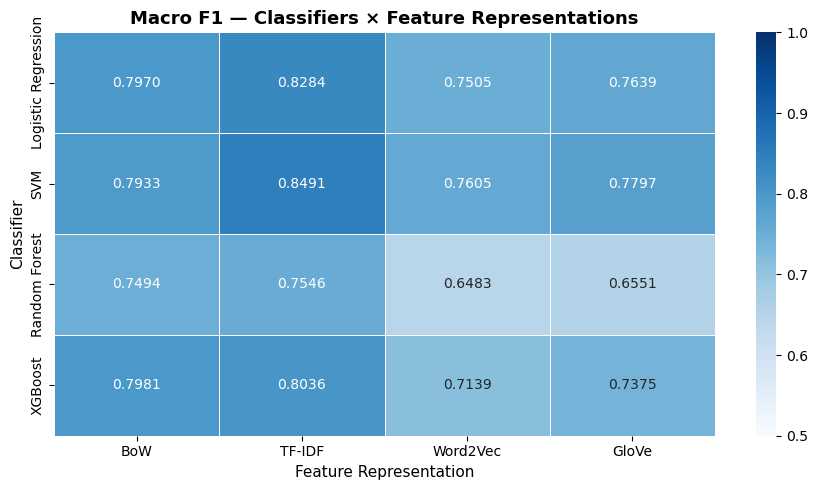

✅ Comparison heatmap saved


In [12]:
# Cell 10: Comparison heatmap 
# Pivot: classifiers × representations
pivot_data = {}
for rep in ["BoW", "TF-IDF", "Word2Vec", "GloVe"]:
    pivot_data[rep] = {}
    for clf in ["Logistic Regression", "SVM", "Random Forest", "XGBoost"]:
        key = f"{clf} ({rep})"
        if key in all_results:
            pivot_data[rep][clf] = all_results[key]["Macro F1"]

df_pivot = pd.DataFrame(pivot_data)

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    df_pivot,
    annot=True, fmt=".4f",
    cmap="Blues",
    linewidths=0.5,
    linecolor="white",
    ax=ax,
    vmin=0.5, vmax=1.0,
    annot_kws={"size": 10}
)
ax.set_title("Macro F1 — Classifiers × Feature Representations",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Feature Representation", fontsize=11)
ax.set_ylabel("Classifier", fontsize=11)
plt.tight_layout()
plt.savefig(PLOT_DIR / "09_embedding_comparison_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Comparison heatmap saved")


In [13]:
# Cell 11: Top-5 predictions using best embedding model 
# Identify best embedding (exclude TF-IDF — that was Step 4)
emb_results = {k: v for k, v in all_results.items()
               if v["Representation"] in ["BoW", "Word2Vec", "GloVe"]}
df_emb = pd.DataFrame(emb_results).T.sort_values("Macro F1", ascending=False)
best_emb_row  = df_emb.iloc[0]
best_emb_rep  = best_emb_row["Representation"]
best_emb_clf  = best_emb_row["Classifier"]

print(f"Best embedding model: {best_emb_clf} + {best_emb_rep}")
print(f"Macro F1: {best_emb_row['Macro F1']:.4f}")
print()

# Get the right feature matrix and trained model
rep_map = {
    "BoW":      (X_mahe_bow,   trained_bow),
    "Word2Vec": (X_mahe_w2v,   trained_w2v),
    "GloVe":    (X_mahe_glove, trained_glove),
}
X_mahe_best, trained_best = rep_map[best_emb_rep]
best_clf = trained_best[best_emb_clf]

# Generate top-5 predictions
if best_emb_clf == "XGBoost":
    proba = best_clf.predict_proba(X_mahe_best)
    clf_classes = [label_map_inv[i] for i in range(len(classes))]
else:
    proba = best_clf.predict_proba(X_mahe_best)
    clf_classes = list(best_clf.classes_)

mahe_results = []
for i in range(len(mahe_raw)):
    doc_proba  = proba[i]
    sorted_idx = np.argsort(doc_proba)[::-1]
    top5_sdgs   = [int(clf_classes[j]) for j in sorted_idx[:5]]
    top5_scores = [round(float(doc_proba[j]), 4) for j in sorted_idx[:5]]
    top5_names  = [SDG_NAMES.get(s, f"SDG {s}") for s in top5_sdgs]

    top5_arr   = np.array(top5_scores)
    exp_scores = np.exp(top5_arr - top5_arr.max())
    softmax    = (exp_scores / exp_scores.sum()).round(4)

    mahe_results.append({
        "Title":          mahe_df.iloc[i]["title"] if "title" in mahe_df.columns else mahe_df.iloc[i]["text"][:80],
        "Rank1_SDG":      f"SDG {top5_sdgs[0]}",
        "Rank1_Name":     top5_names[0],
        "Rank1_Score":    top5_scores[0],
        "Rank2_SDG":      f"SDG {top5_sdgs[1]}",
        "Rank2_Name":     top5_names[1],
        "Rank2_Score":    top5_scores[1],
        "Rank3_SDG":      f"SDG {top5_sdgs[2]}",
        "Rank3_Name":     top5_names[2],
        "Rank3_Score":    top5_scores[2],
        "Rank4_SDG":      f"SDG {top5_sdgs[3]}",
        "Rank4_Name":     top5_names[3],
        "Rank4_Score":    top5_scores[3],
        "Rank5_SDG":      f"SDG {top5_sdgs[4]}",
        "Rank5_Name":     top5_names[4],
        "Rank5_Score":    top5_scores[4],
        "Top5_SDGs":      ", ".join([f"SDG {s}" for s in top5_sdgs]),
        "Softmax_Scores": ", ".join([str(s) for s in softmax]),
    })

df_mahe_emb = pd.DataFrame(mahe_results)
df_mahe_emb.to_csv(RESULTS_DIR / "mahe_top5_glove.csv", index=False, encoding="utf-8-sig")

print(f"✅ Top-5 predictions saved: data/results/mahe_top5_glove.csv")
print()
print("Sample predictions:")
print(df_mahe_emb[["Title","Rank1_SDG","Rank1_Name","Top5_SDGs"]].head(5).to_string())


Best embedding model: XGBoost + BoW
Macro F1: 0.7981

✅ Top-5 predictions saved: data/results/mahe_top5_glove.csv

Sample predictions:
                                                                                                                 Title Rank1_SDG                               Rank1_Name                             Top5_SDGs
0                 Analytical and bioanalytical HPLC method for simultaneous estimation of 5-fluorouracil and sonidegib     SDG 6               Clean Water and Sanitation  SDG 6, SDG 14, SDG 9, SDG 12, SDG 11
1                           ‘Solving’ as a key course learning outcome (CLO) in postgraduate (PG) management education     SDG 4                        Quality Education   SDG 4, SDG 16, SDG 9, SDG 8, SDG 11
2                 Remote Sensing: A Satellite-Based Advanced Geospatial Technology Boon in Natural Resource Management     SDG 9  Industry, Innovation and Infrastructure  SDG 9, SDG 11, SDG 12, SDG 7, SDG 15
3  Spatial circularity in sustain

In [14]:
# Cell 12: Step 5 summary 
tfidf_best  = df_step4["Macro F1"].max()
emb_best_f1 = float(best_emb_row["Macro F1"])
improvement = emb_best_f1 - tfidf_best

print("=" * 62)
print("  STEP 5 — WORD EMBEDDINGS SUMMARY")
print("=" * 62)
print()
print("  Representations compared:")
print(f"    BoW       best F1 : {max(v['Macro F1'] for v in results_bow.values()):.4f}")
print(f"    Word2Vec  best F1 : {max(v['Macro F1'] for v in results_w2v.values()):.4f}")
print(f"    GloVe     best F1 : {max(v['Macro F1'] for v in results_glove.values()):.4f}")
print()
print(f"  Step 4 TF-IDF best  : {tfidf_best:.4f} (SVM)")
print(f"  Step 5 best overall : {emb_best_f1:.4f} ({best_emb_clf} + {best_emb_rep})")
diff_str = f"+{improvement:.4f}" if improvement >= 0 else f"{improvement:.4f}"
print(f"  Change vs TF-IDF    : {diff_str}")
print()
if improvement > 0:
    print("  ✅ Embeddings improved over TF-IDF baseline")
    print("     Semantic representations capture meaning TF-IDF misses")
elif improvement > -0.01:
    print("  ≈  Similar performance — TF-IDF is competitive at this scale")
    print("     Embeddings may improve further with BERT in Step 7")
else:
    print("  ⚠  TF-IDF outperforms embeddings")
    print("     Common for short texts — TF-IDF keyword matching is very effective")
    print("     BERT contextual embeddings in Step 7 should recover the gap")
print()
print("  Word2Vec model saved : data/models/word2vec_osdg.model")
print("  Comparison heatmap   : data/plots/09_embedding_comparison_heatmap.png")
print()
print("✅ Step 5 complete → next: step6_similarity.ipynb")
print("=" * 62)


  STEP 5 — WORD EMBEDDINGS SUMMARY

  Representations compared:
    BoW       best F1 : 0.7981
    Word2Vec  best F1 : 0.7605
    GloVe     best F1 : 0.7797

  Step 4 TF-IDF best  : 0.8491 (SVM)
  Step 5 best overall : 0.7981 (XGBoost + BoW)
  Change vs TF-IDF    : -0.0510

  ⚠  TF-IDF outperforms embeddings
     Common for short texts — TF-IDF keyword matching is very effective
     BERT contextual embeddings in Step 7 should recover the gap

  Word2Vec model saved : data/models/word2vec_osdg.model
  Comparison heatmap   : data/plots/09_embedding_comparison_heatmap.png

✅ Step 5 complete → next: step6_similarity.ipynb
